In [3]:
# !pip install mplfinance

In [38]:
import os
import pandas as pd
import mplfinance as mpf

def plot_ene_for_stocks(stock_configs):
    """
    根据传入的股票配置列表绘制ENE图表。

    参数：
        stock_configs (list of dict): 每个字典包含以下字段：
            - 'name': 股票名称（用于标题）
            - 'path': CSV 文件路径
            - 'N': 均线天数
            - 'M1': 上轨比例
            - 'M2': 下轨比例
            - 'years': 可视化年数（默认1）
    """
    for config in stock_configs:
        name = config.get('name', 'Unnamed')
        path = config['path']
        N = config['N']
        M1 = config['M1']
        M2 = config['M2']
        years = config.get('years', 1)

        if not os.path.exists(path):
            print(f"[错误] 找不到文件: {path}")
            continue

        # 读取 CSV 数据
        df = pd.read_csv(path)

        # 将时间戳列转为日期时间格式（毫秒 -> 日期）
        df['Date'] = pd.to_datetime(df['t'], unit='ms')

        # 设置索引为日期
        df.set_index('Date', inplace=True)

        # 重命名列，以符合 mplfinance 的要求
        df.rename(columns={
            'o': 'Open',
            'h': 'High',
            'l': 'Low',
            'c': 'Close',
            'v': 'Volume'
        }, inplace=True)

        # 留足均线计算天数
        df = df.tail(int(365 * years) + N)

        # 计算 ENE
        ma = df['Close'].rolling(window=N).mean()
        df['UPPER'] = ma * (1 + M1)
        df['LOWER'] = ma * (1 - M2)
        df['ENE'] = (df['UPPER'] + df['LOWER']) / 2

        # 保留可视化天数
        df = df.tail(int(365 * years))

        print(df[-1:])

        # 创建附加的绘图数据
        addplots = [
            mpf.make_addplot(df['UPPER'], color='green', linestyle='--', width=0.8),
            mpf.make_addplot(df['LOWER'], color='red', linestyle='--', width=0.8),
            mpf.make_addplot(df['ENE'], color='blue', linestyle='-', width=1)
        ]

        # 绘制蜡烛图并添加 ENE 图
        mpf.plot(df, type='candle', style='charles',
                 title=f"{name} ENE (N={N}, M1={M1*100:.0f}%, M2={M2*100:.0f}%)",
                 ylabel='Price', figsize=(20, 6),
                 addplot=addplots, volume=True)

## SQQQ

                          Volume       vw   Open  Close   High    Low  \
Date                                                                    
2025-05-07 04:00:00  119060188.0  30.0066  29.84   29.6  30.83  29.15   

                                 t       n      UPPER      LOWER        ENE  
Date                                                                         
2025-05-07 04:00:00  1746590400000  286105  34.435227  27.610227  31.022727  


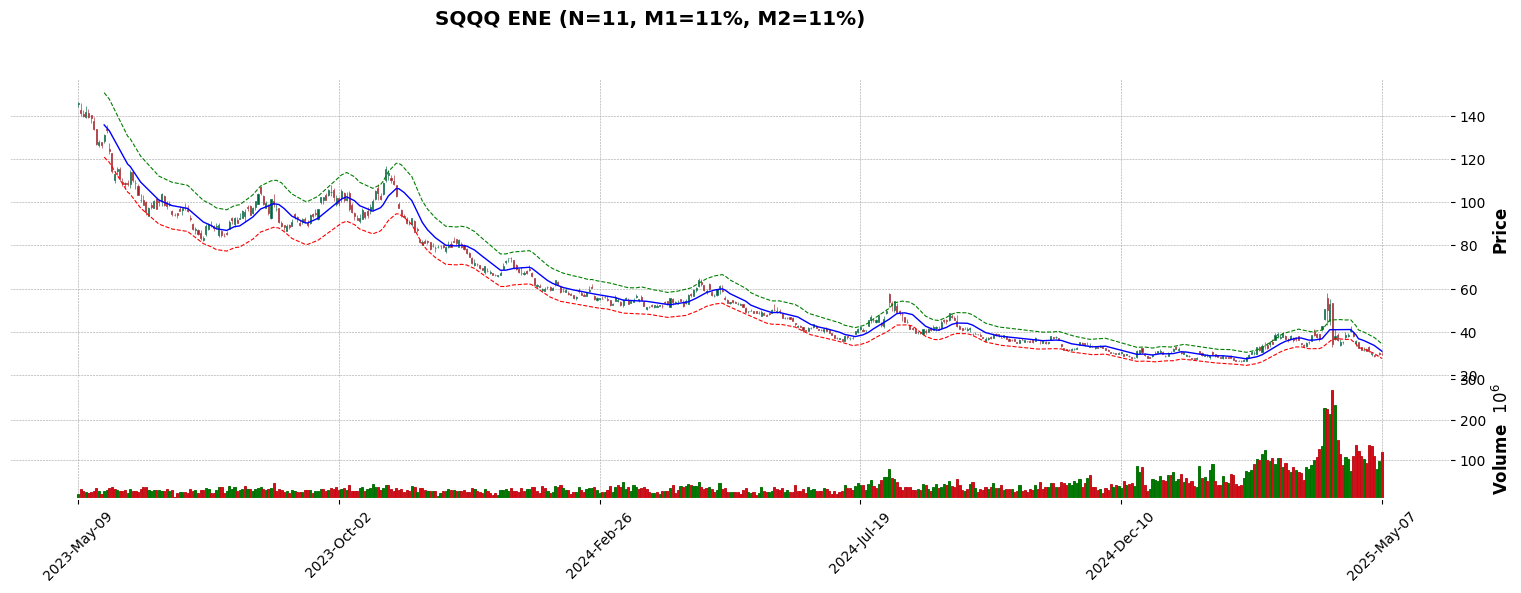

                          Volume       vw   Open  Close   High    Low  \
Date                                                                    
2025-05-07 04:00:00  119060188.0  30.0066  29.84   29.6  30.83  29.15   

                                 t       n     UPPER    LOWER       ENE  
Date                                                                     
2025-05-07 04:00:00  1746590400000  286105  38.79904  29.4457  34.12237  


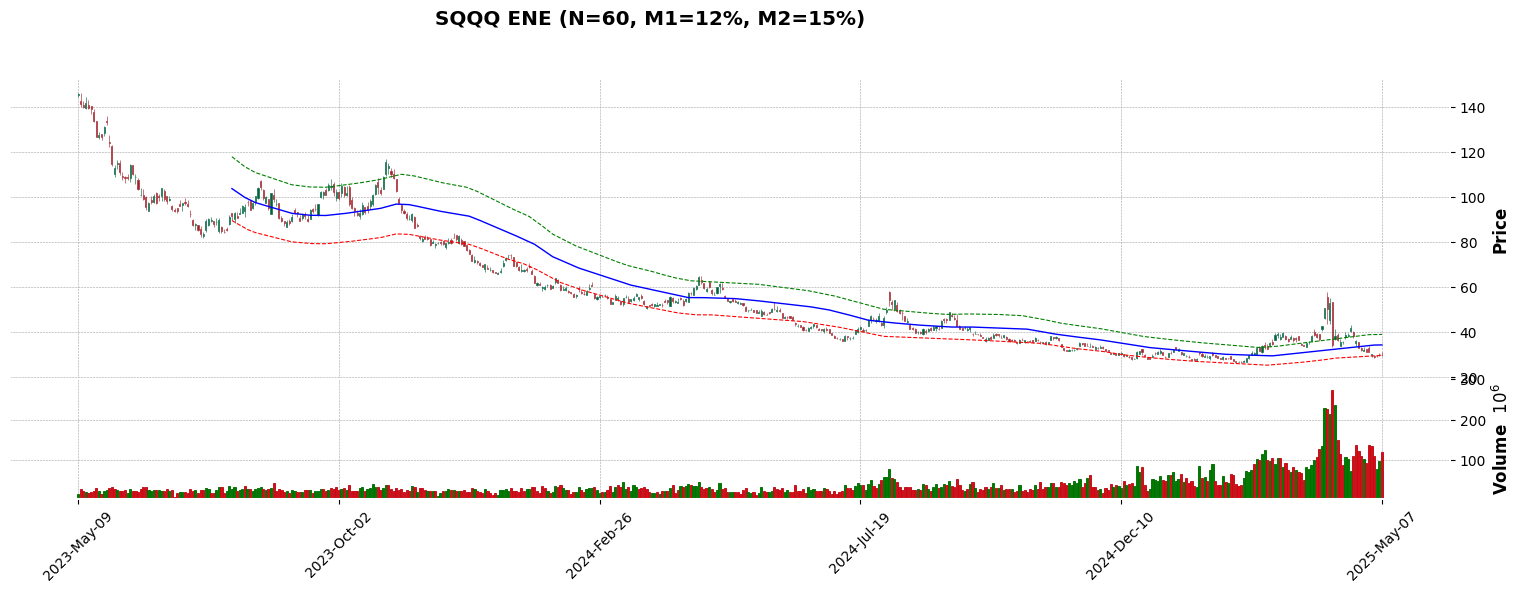

                          Volume       vw   Open  Close   High    Low  \
Date                                                                    
2025-05-07 04:00:00  119060188.0  30.0066  29.84   29.6  30.83  29.15   

                                 t       n      UPPER     LOWER        ENE  
Date                                                                        
2025-05-07 04:00:00  1746590400000  286105  37.419804  24.40422  30.912012  


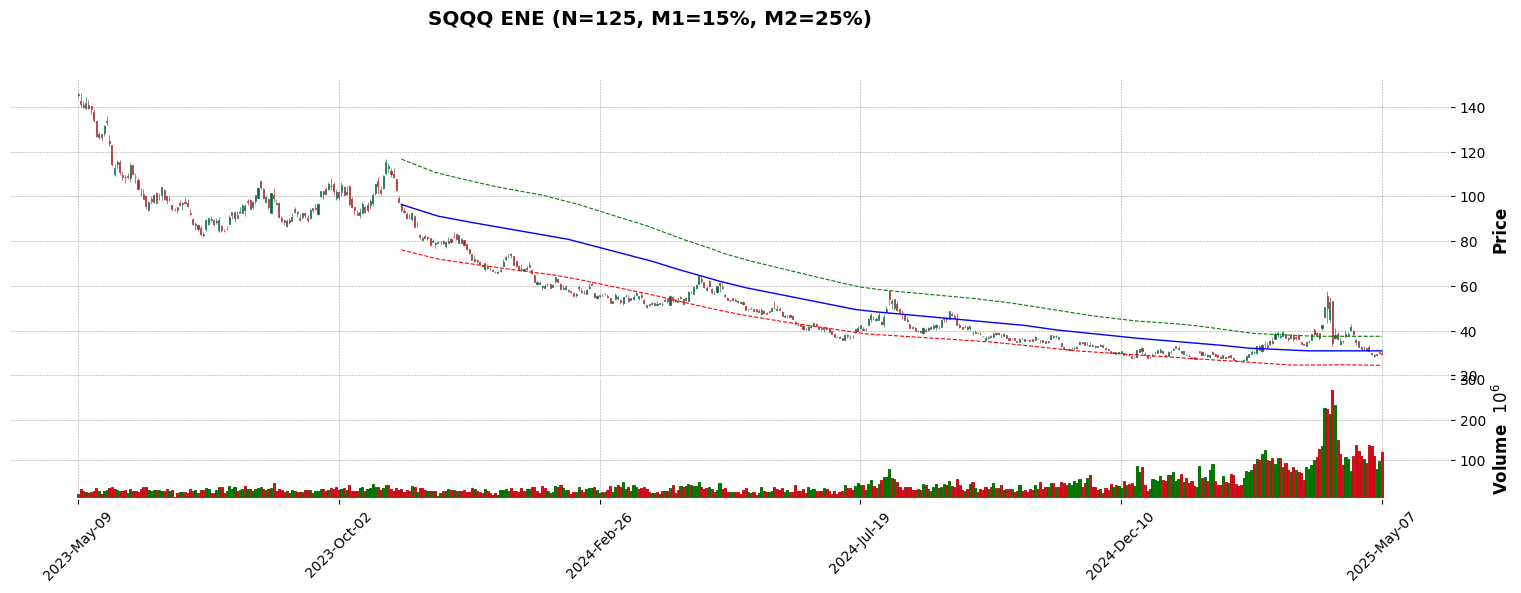

In [96]:
ticker_name = 'SQQQ'
data_date = '2025-05-08'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 60,
        'M1': 0.12,
        'M2': 0.15,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

## SLV

                         Volume       vw   Open  Close   High    Low  \
Date                                                                   
2025-05-07 04:00:00  14119054.0  29.6025  29.77  29.49  29.87  29.32   

                                 t      n      UPPER      LOWER        ENE  
Date                                                                        
2025-05-07 04:00:00  1746590400000  35037  32.550373  27.175082  29.862727  


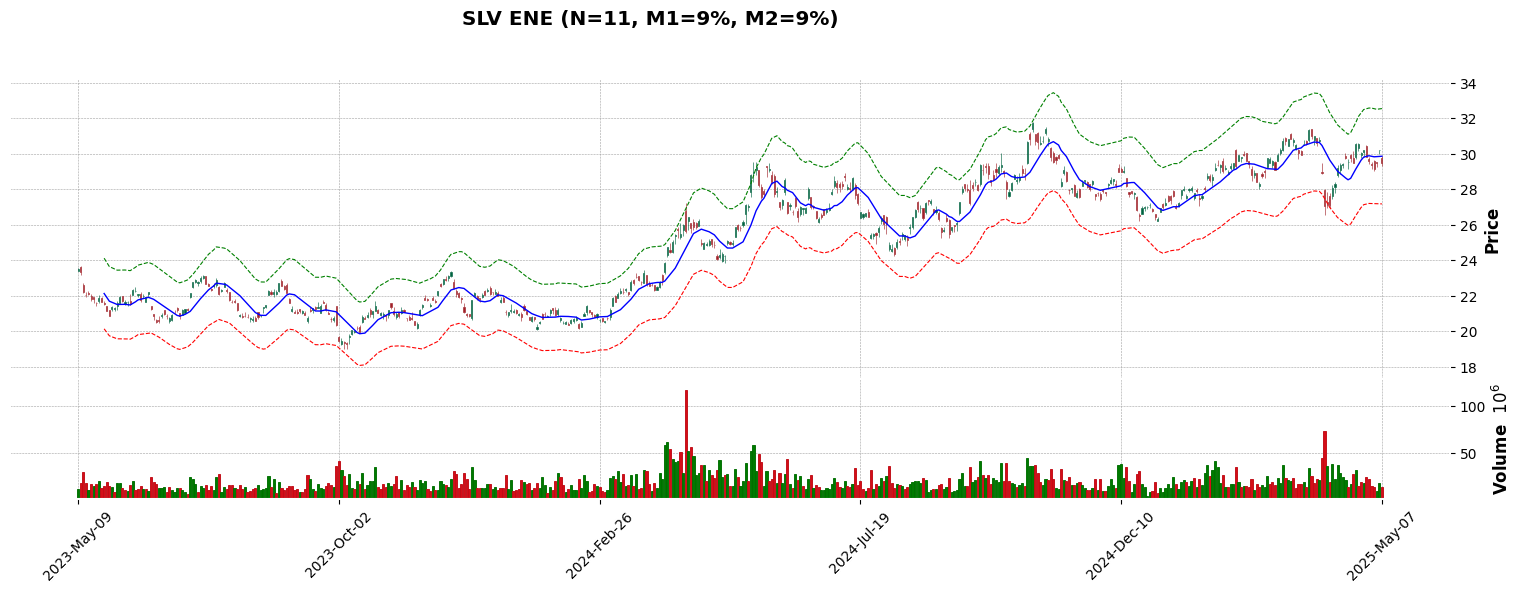

                         Volume       vw   Open  Close   High    Low  \
Date                                                                   
2025-05-07 04:00:00  14119054.0  29.6025  29.77  29.49  29.87  29.32   

                                 t      n      UPPER      LOWER        ENE  
Date                                                                        
2025-05-07 04:00:00  1746590400000  35037  33.147627  26.577827  29.862727  


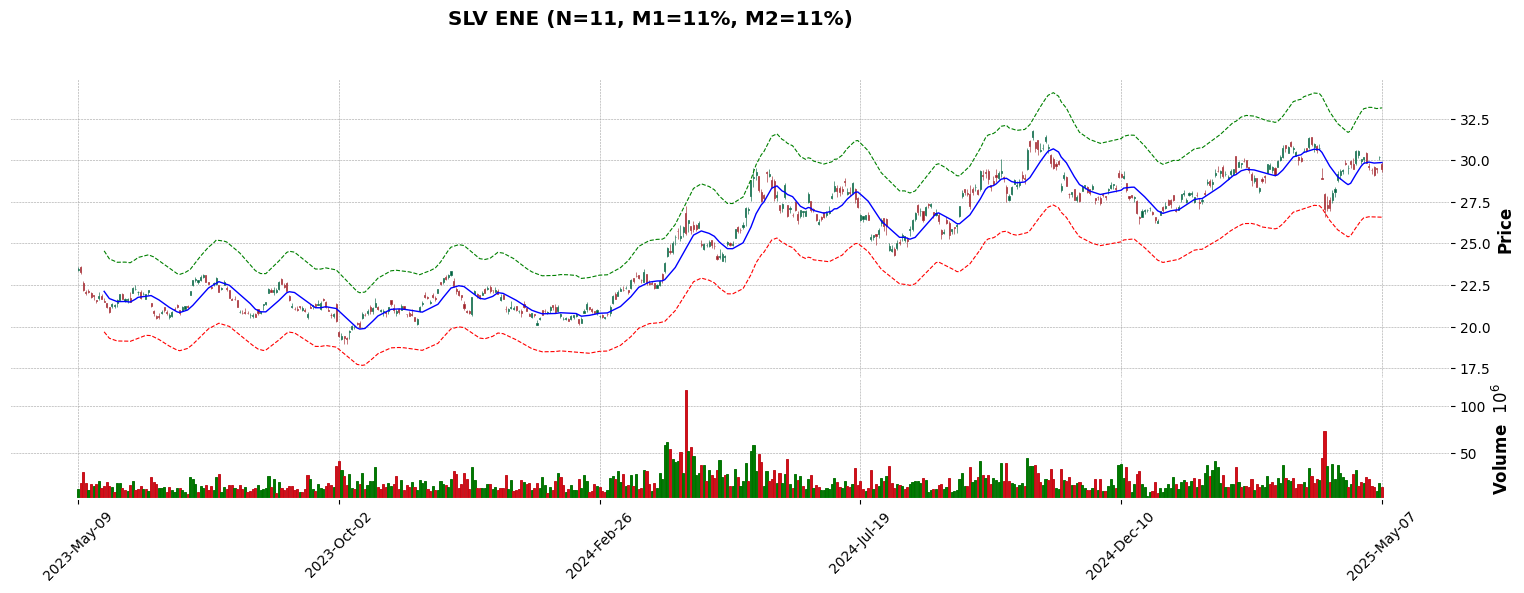

                         Volume       vw   Open  Close   High    Low  \
Date                                                                   
2025-05-07 04:00:00  14119054.0  29.6025  29.77  29.49  29.87  29.32   

                                 t      n      UPPER     LOWER        ENE  
Date                                                                       
2025-05-07 04:00:00  1746590400000  35037  33.068664  21.56652  27.317592  


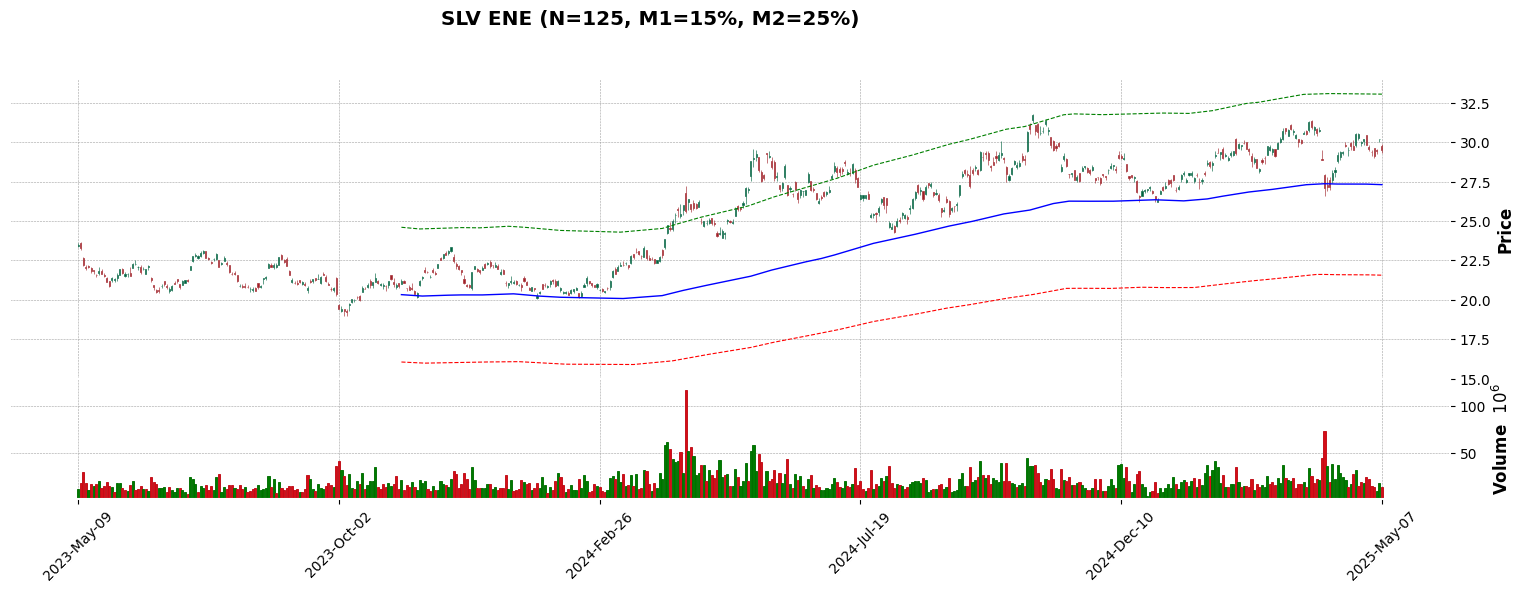

In [83]:
ticker_name = 'SLV'
data_date = '2025-05-08'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

## GLD

                         Volume       vw    Open   Close    High    Low  \
Date                                                                      
2025-05-06 04:00:00  11445270.0  313.789  313.12  315.48  315.62  311.4   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  123682  333.367582  278.316055  305.841818  


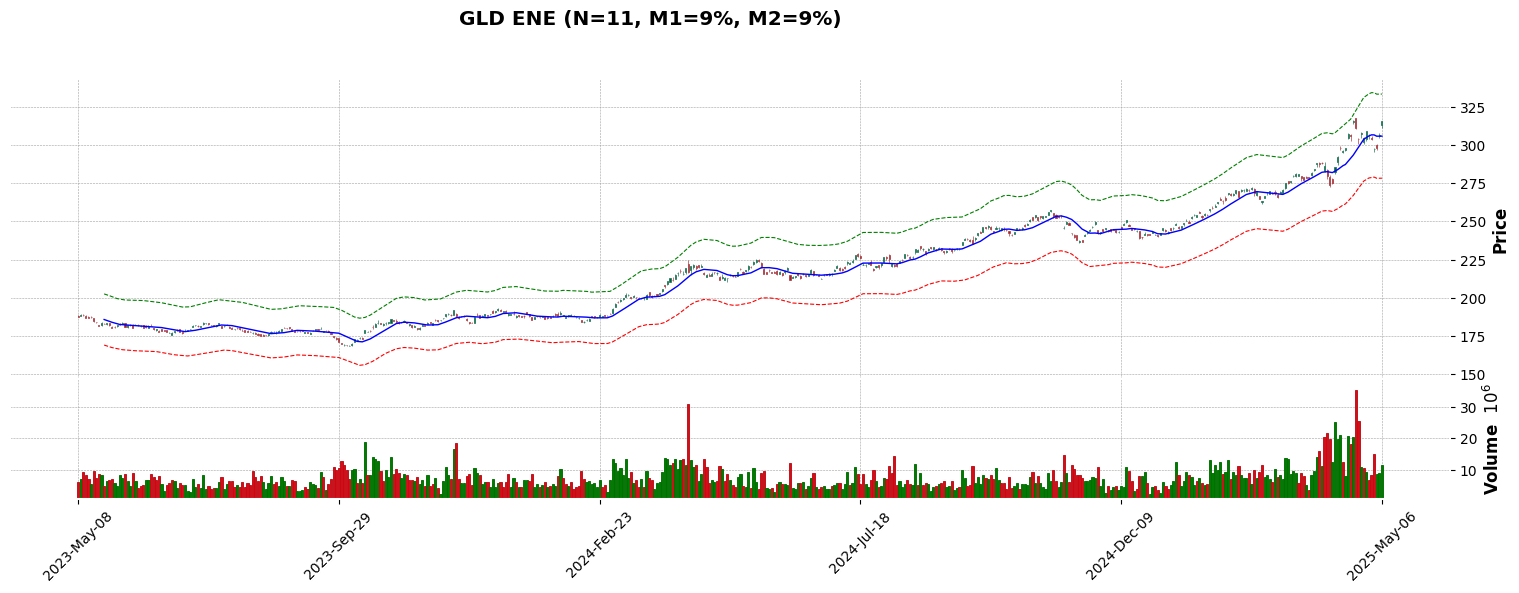

                         Volume       vw    Open   Close    High    Low  \
Date                                                                      
2025-05-06 04:00:00  11445270.0  313.789  313.12  315.48  315.62  311.4   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  123682  339.484418  272.199218  305.841818  


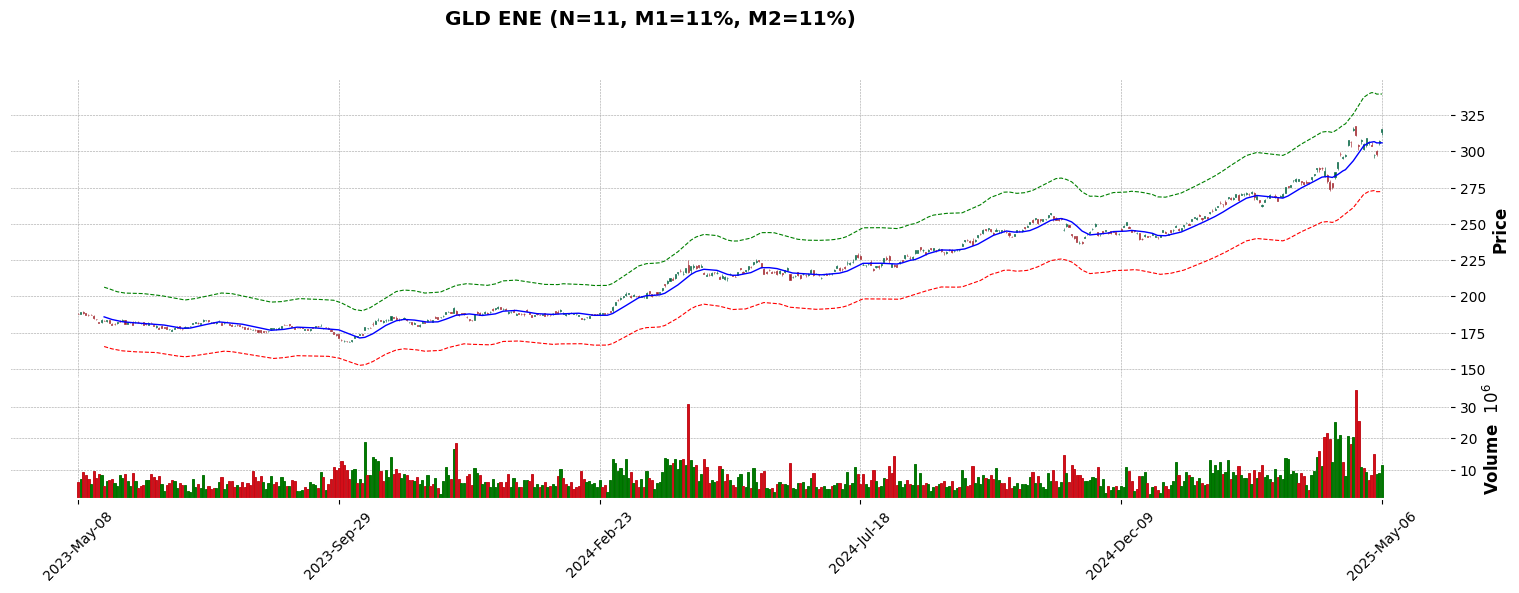

                         Volume       vw    Open   Close    High    Low  \
Date                                                                      
2025-05-06 04:00:00  11445270.0  313.789  313.12  315.48  315.62  311.4   

                                 t       n       UPPER      LOWER         ENE  
Date                                                                           
2025-05-06 04:00:00  1746504000000  123682  304.312724  198.46482  251.388772  


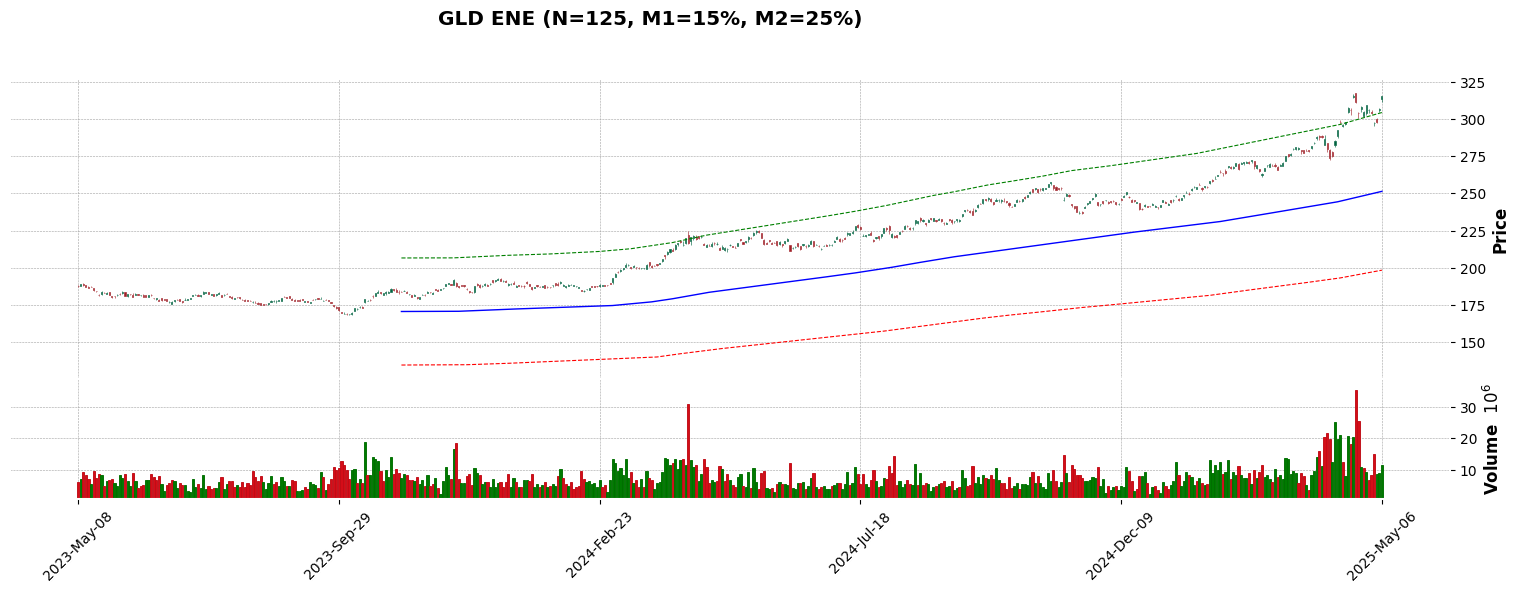

In [64]:
ticker_name = 'GLD'
data_date = '2025-05-07'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

## CVX

                        Volume        vw     Open   Close    High     Low  \
Date                                                                        
2025-05-08 04:00:00  8669305.0  137.5532  136.685  137.04  138.89  136.47   

                                 t       n     UPPER     LOWER     ENE  
Date                                                                    
2025-05-08 04:00:00  1746676800000  117174  149.8205  125.0795  137.45  


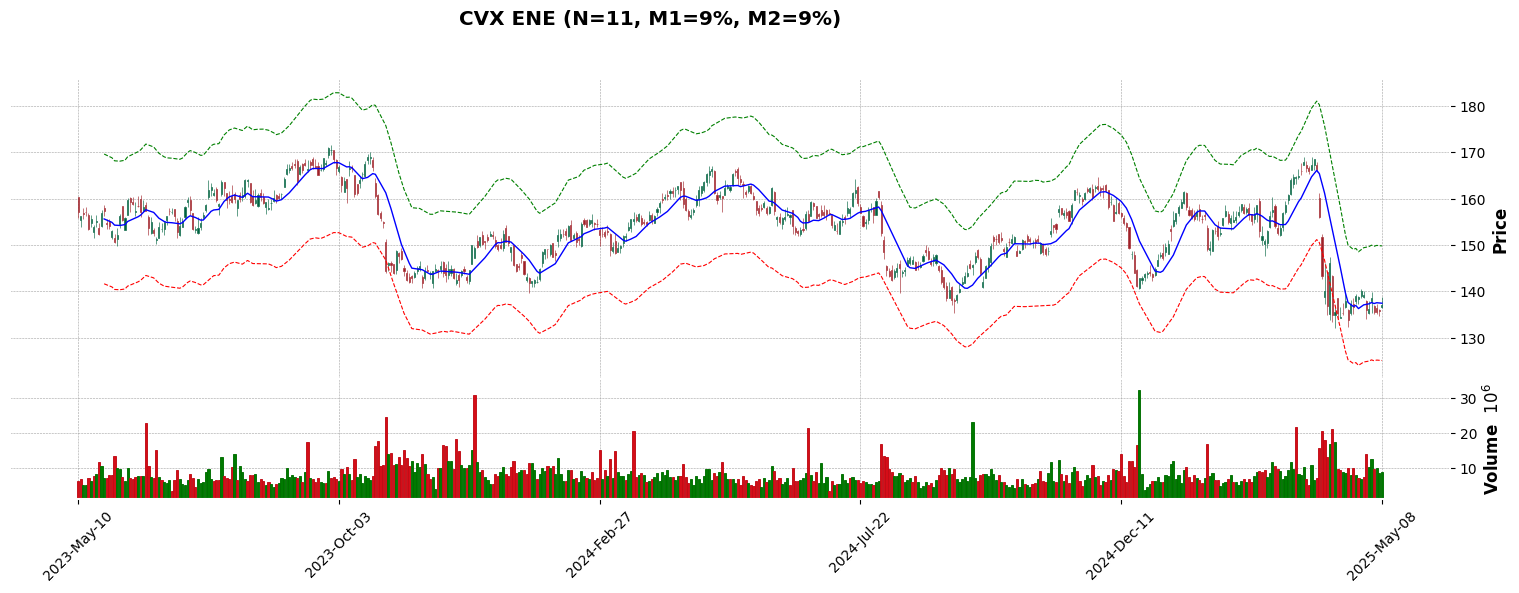

                        Volume        vw     Open   Close    High     Low  \
Date                                                                        
2025-05-08 04:00:00  8669305.0  137.5532  136.685  137.04  138.89  136.47   

                                 t       n      UPPER       LOWER         ENE  
Date                                                                           
2025-05-08 04:00:00  1746676800000  117174  168.42952  127.825975  148.127747  


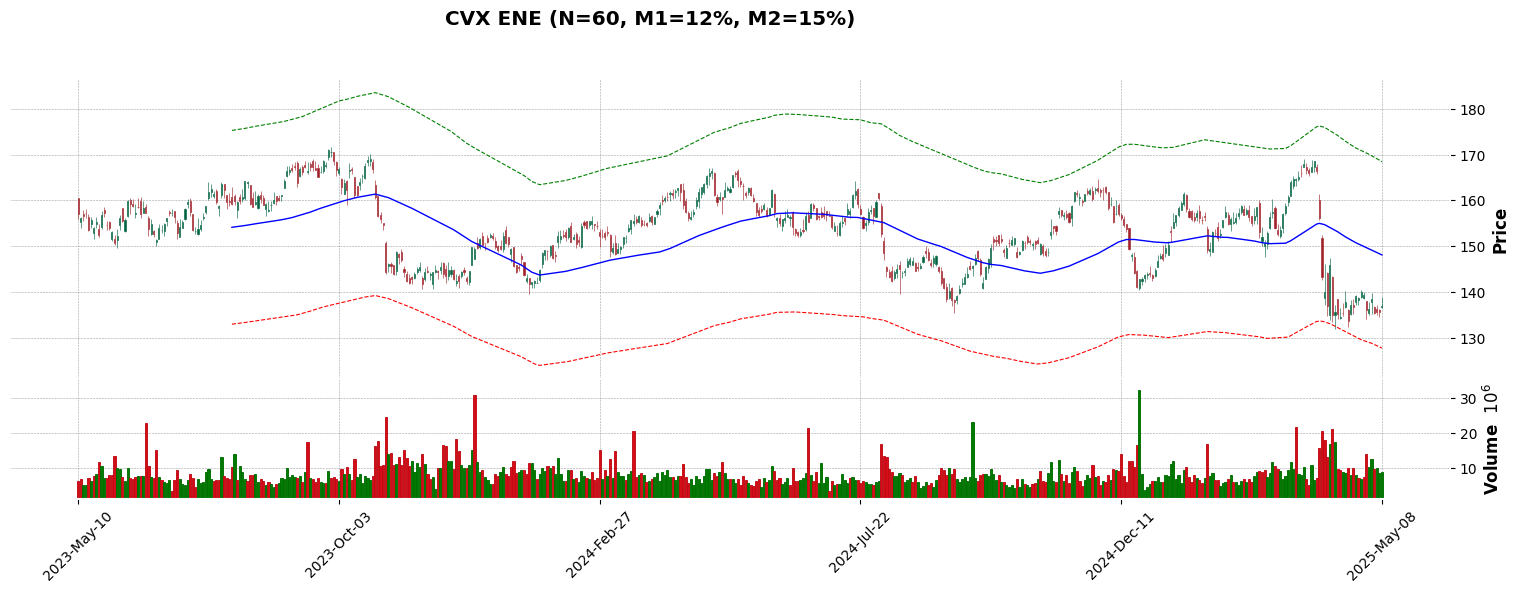

                        Volume        vw     Open   Close    High     Low  \
Date                                                                        
2025-05-08 04:00:00  8669305.0  137.5532  136.685  137.04  138.89  136.47   

                                 t       n       UPPER      LOWER         ENE  
Date                                                                           
2025-05-08 04:00:00  1746676800000  117174  175.401864  114.39252  144.897192  


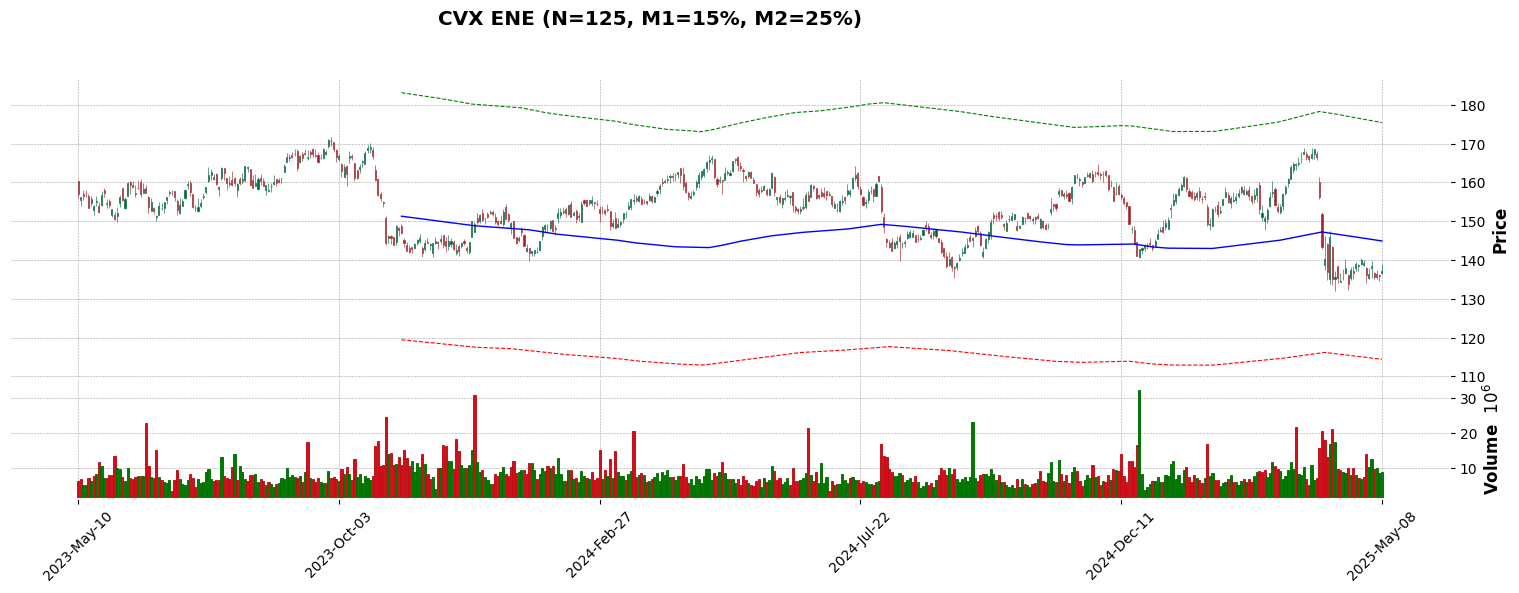

In [100]:
ticker_name = 'CVX'
data_date = '2025-05-09'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 2
    },
    # {
    #     'name': ticker_name,
    #     'path': data_path,
    #     'N': 11,
    #     'M1': 0.11,
    #     'M2': 0.11,
    #     'years': 2
    # },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 60,
        'M1': 0.12,
        'M2': 0.15,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

## GOOGL

                         Volume        vw    Open   Close   High     Low  \
Date                                                                       
2025-05-06 04:00:00  21277210.0  163.3455  162.17  163.23  164.8  161.19   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  263734  174.439636  145.633091  160.036364  


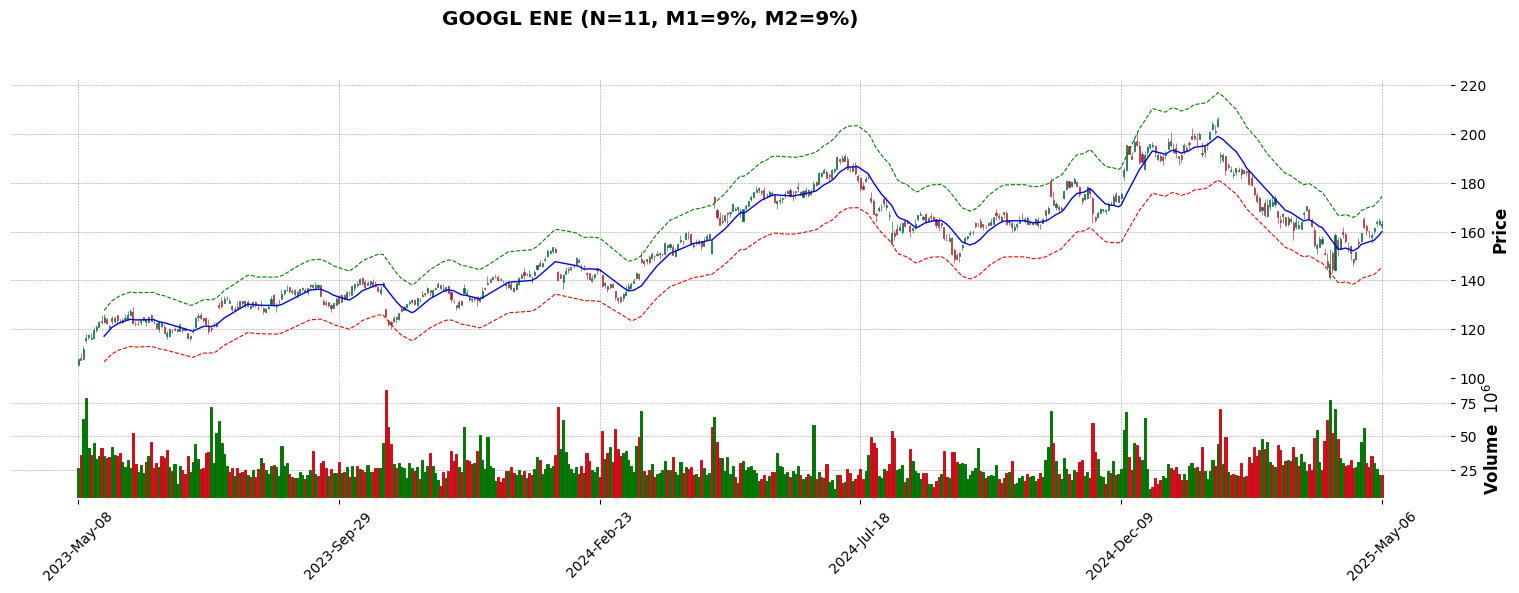

                         Volume        vw    Open   Close   High     Low  \
Date                                                                       
2025-05-06 04:00:00  21277210.0  163.3455  162.17  163.23  164.8  161.19   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  263734  177.640364  142.432364  160.036364  


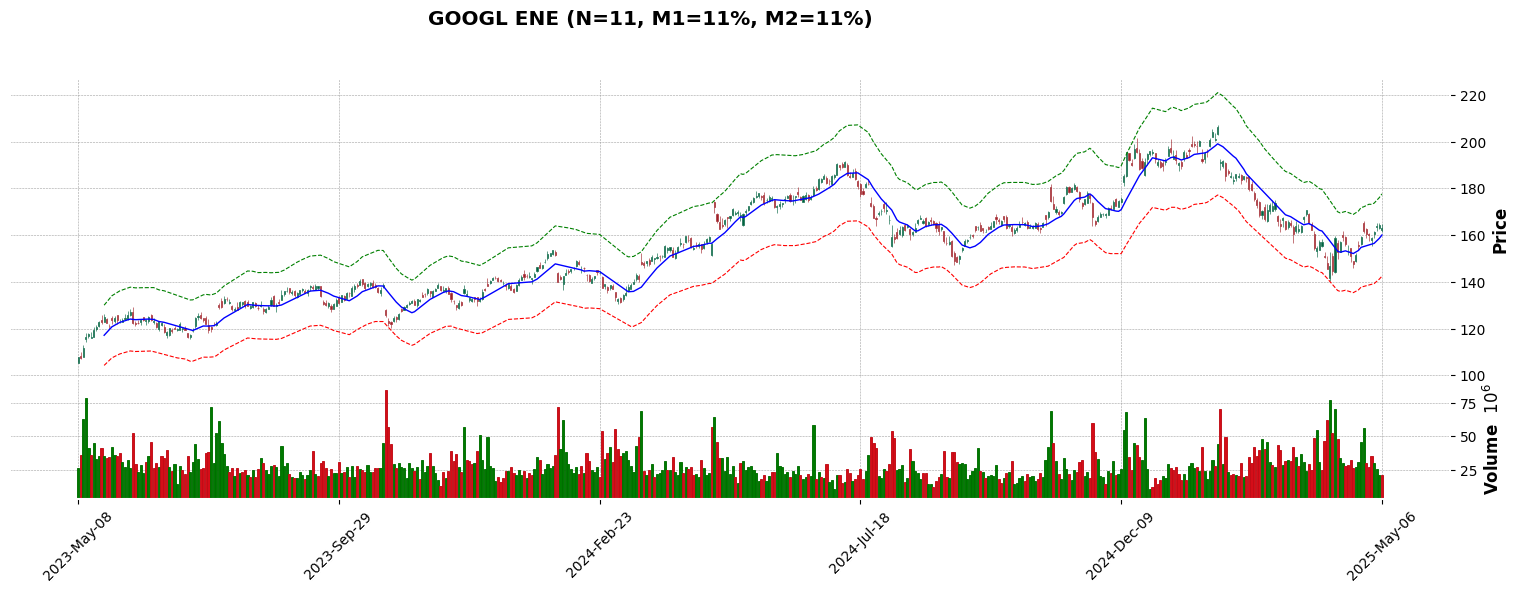

                         Volume        vw    Open   Close   High     Low  \
Date                                                                       
2025-05-06 04:00:00  21277210.0  163.3455  162.17  163.23  164.8  161.19   

                                 t       n       UPPER      LOWER         ENE  
Date                                                                           
2025-05-06 04:00:00  1746504000000  263734  202.422448  132.01464  167.218544  


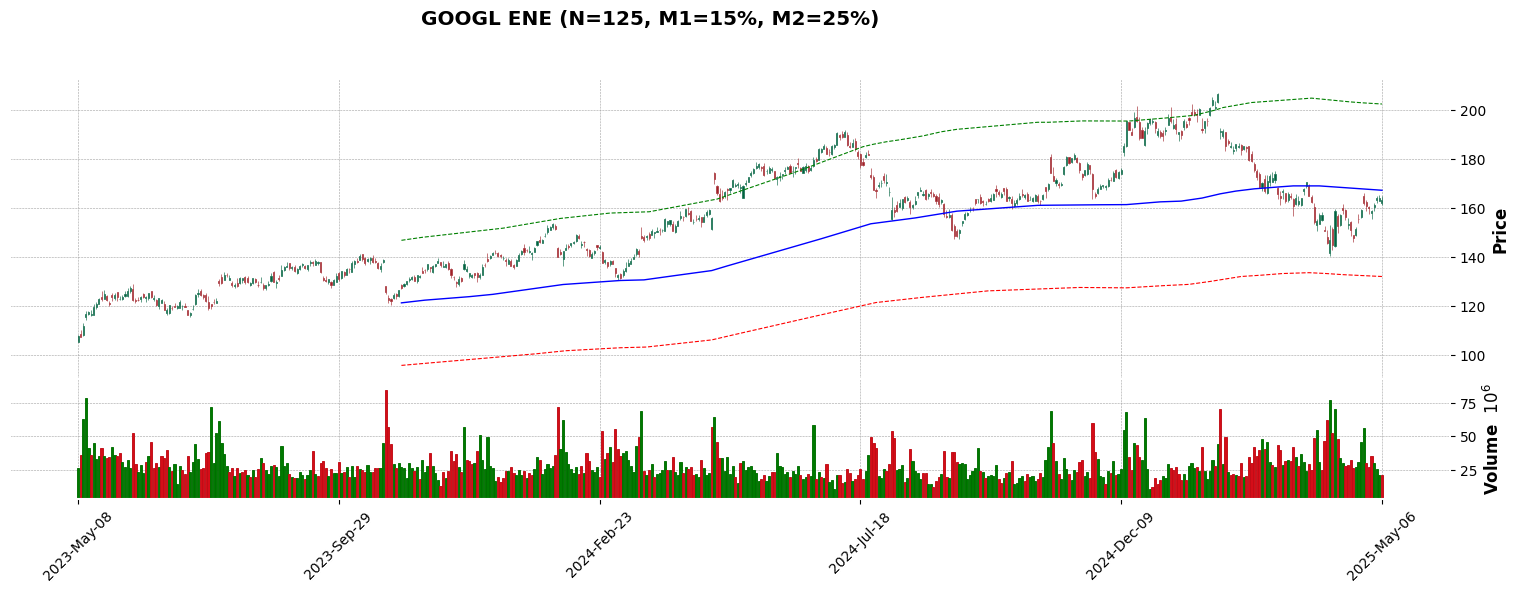

In [66]:
ticker_name = 'GOOGL'
data_date = '2025-05-07'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

                         Volume        vw    Open   Close    High     Low  \
Date                                                                        
2025-05-06 04:00:00  51216482.0  198.8453  198.21  198.51  200.65  197.02   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  529849  225.125627  187.948918  206.537273  


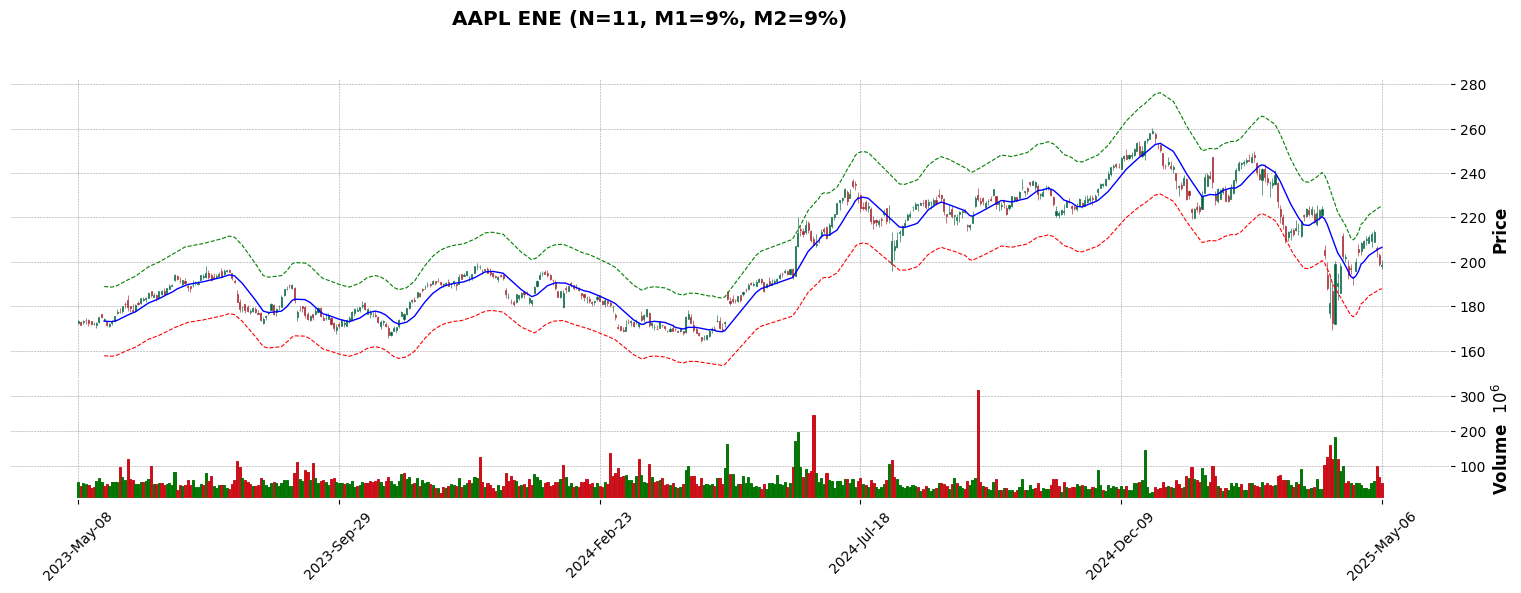

                         Volume        vw    Open   Close    High     Low  \
Date                                                                        
2025-05-06 04:00:00  51216482.0  198.8453  198.21  198.51  200.65  197.02   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  529849  229.256373  183.818173  206.537273  


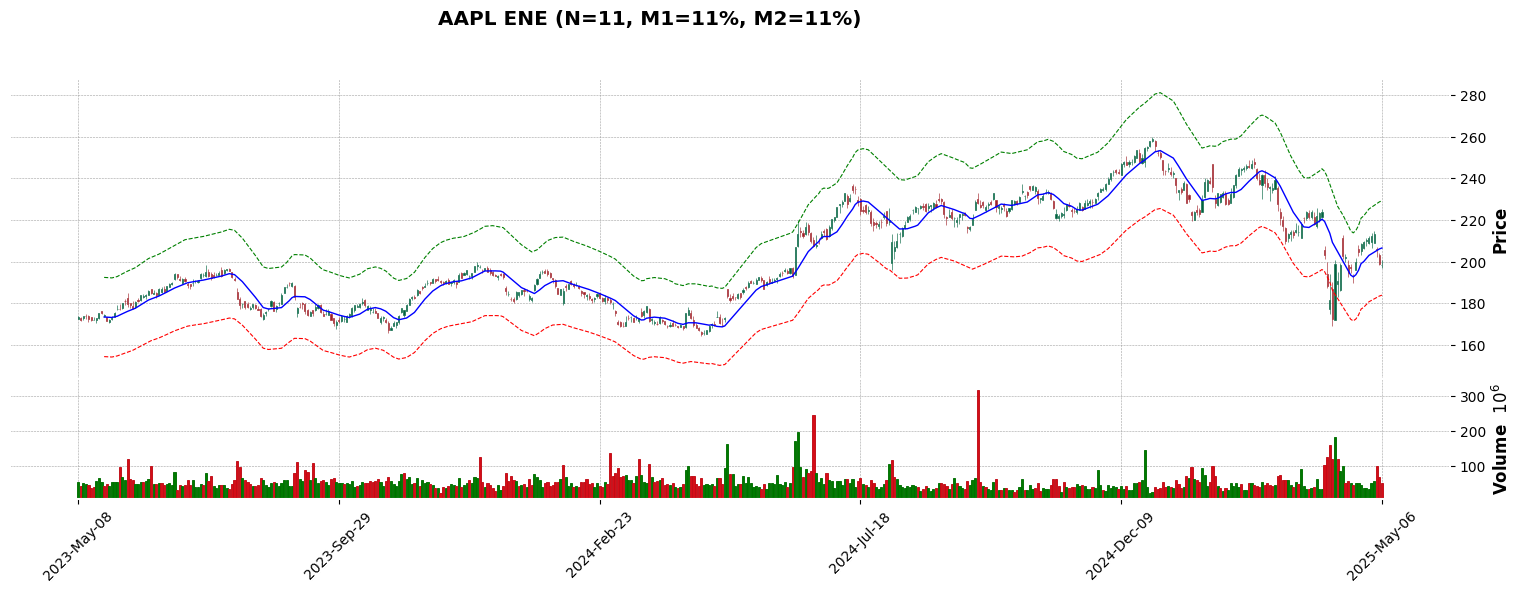

                         Volume        vw    Open   Close    High     Low  \
Date                                                                        
2025-05-06 04:00:00  51216482.0  198.8453  198.21  198.51  200.65  197.02   

                                 t       n       UPPER      LOWER         ENE  
Date                                                                           
2025-05-06 04:00:00  1746504000000  529849  262.294484  171.06162  216.678052  


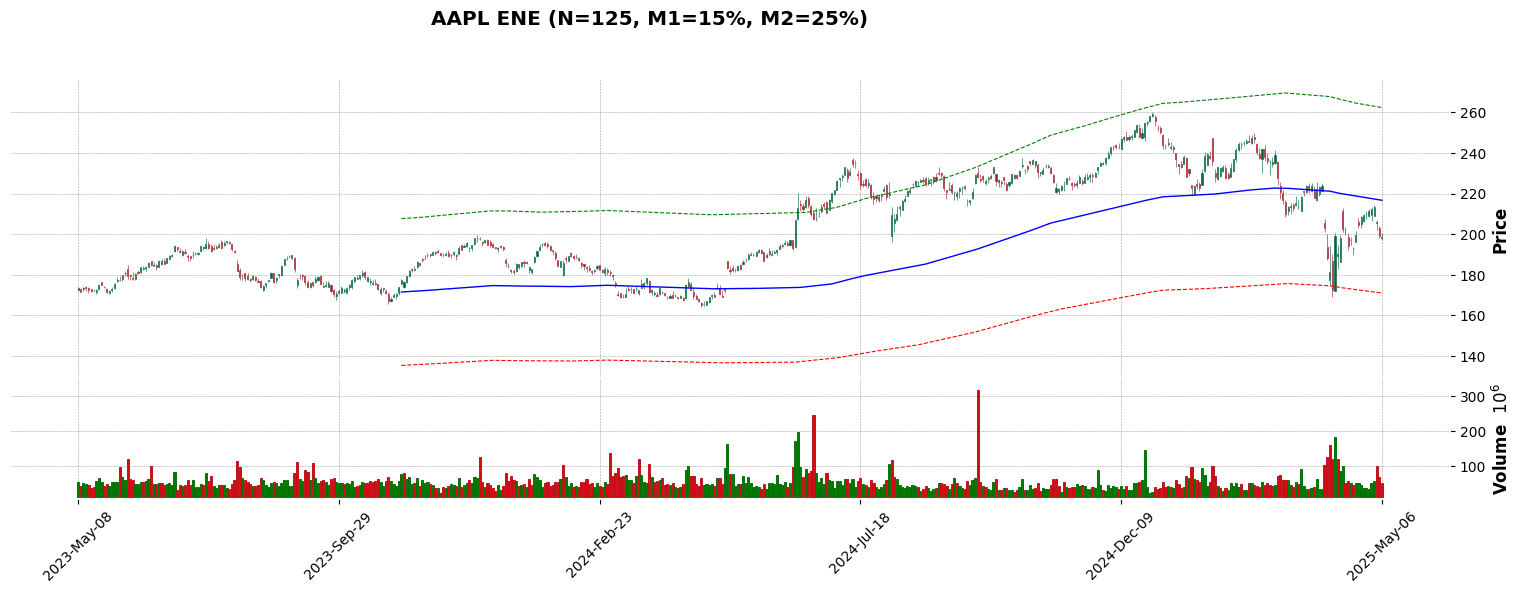

In [67]:
ticker_name = 'AAPL'
data_date = '2025-05-07'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

                        Volume        vw    Open  Close    High     Low  \
Date                                                                      
2025-05-06 04:00:00  3169596.0  208.7122  206.02  208.6  209.83  205.92   

                                 t      n     UPPER     LOWER     ENE  
Date                                                                   
2025-05-06 04:00:00  1746504000000  50547  219.0355  182.8645  200.95  


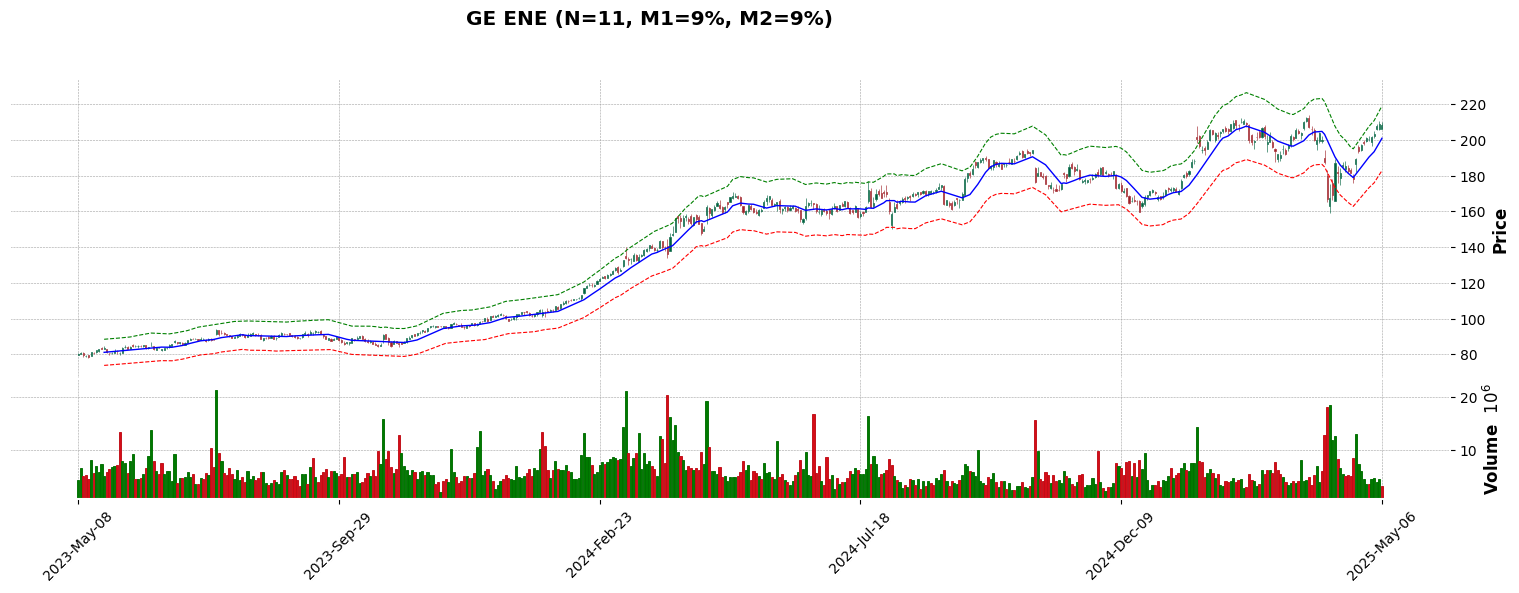

                        Volume        vw    Open  Close    High     Low  \
Date                                                                      
2025-05-06 04:00:00  3169596.0  208.7122  206.02  208.6  209.83  205.92   

                                 t      n     UPPER     LOWER     ENE  
Date                                                                   
2025-05-06 04:00:00  1746504000000  50547  223.0545  178.8455  200.95  


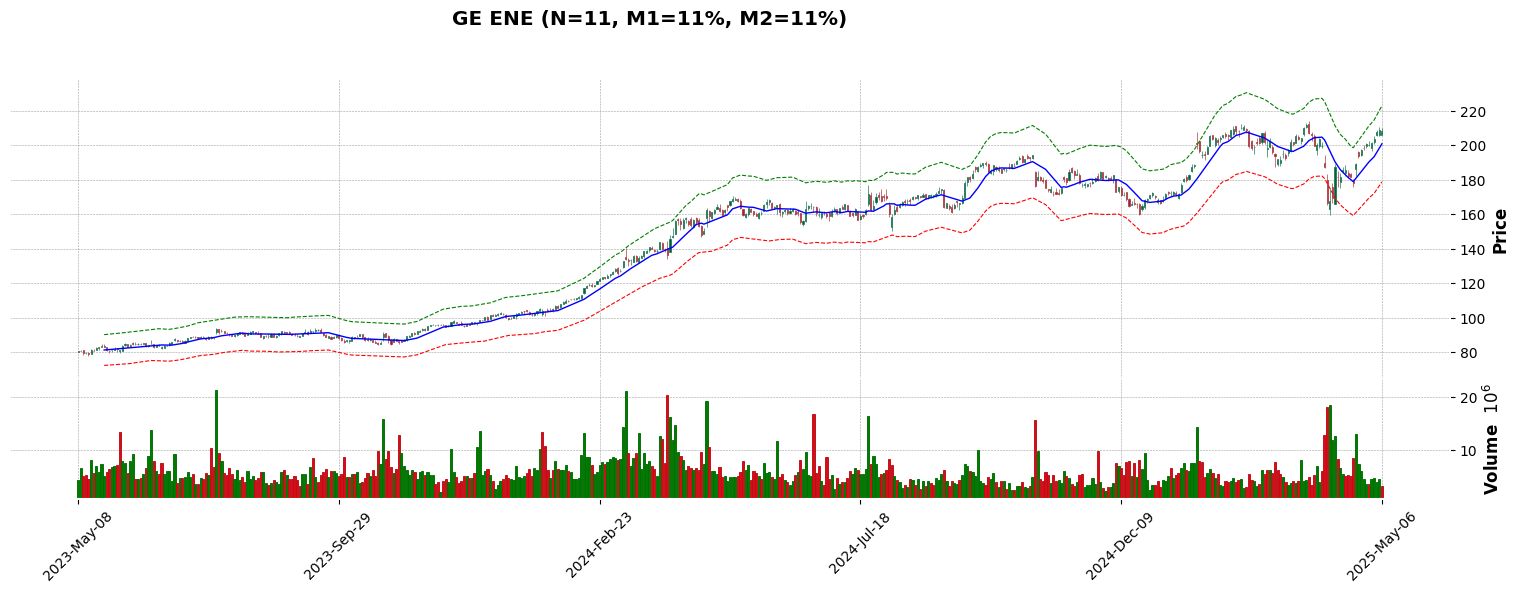

                        Volume        vw    Open  Close    High     Low  \
Date                                                                      
2025-05-06 04:00:00  3169596.0  208.7122  206.02  208.6  209.83  205.92   

                                 t      n      UPPER     LOWER        ENE  
Date                                                                       
2025-05-06 04:00:00  1746504000000  50547  216.84354  141.4197  179.13162  


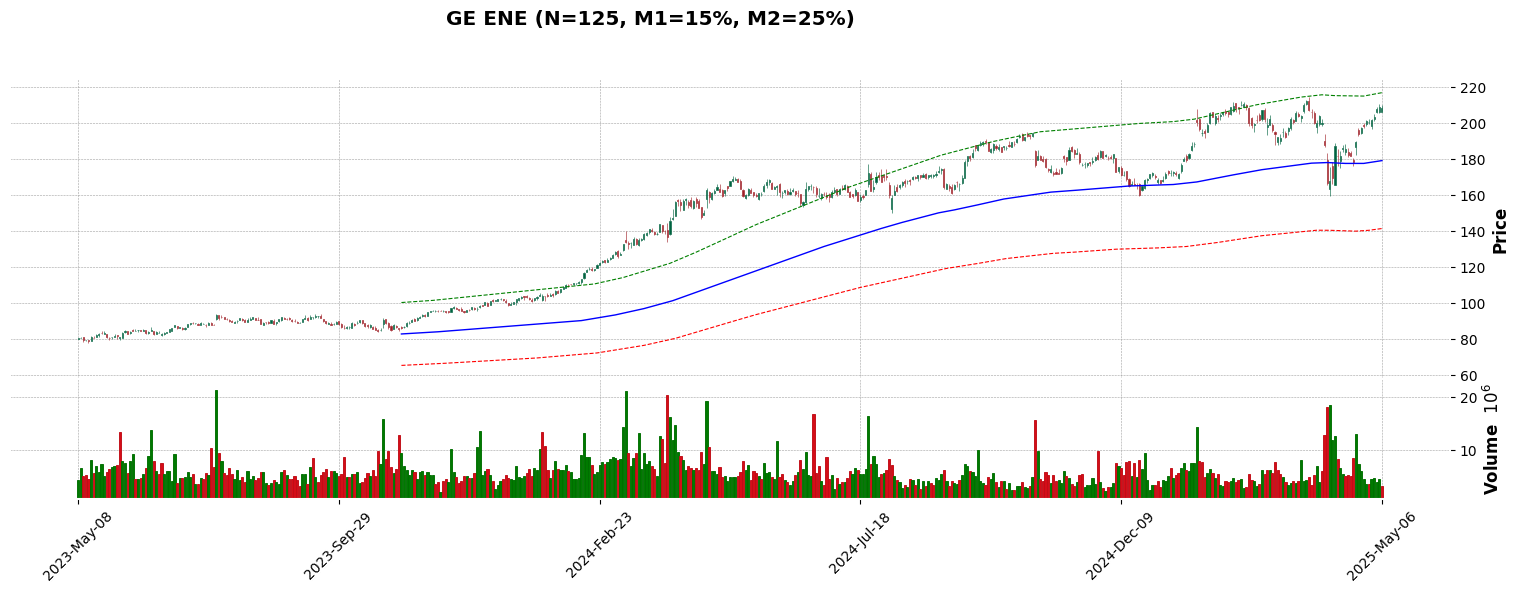

In [70]:
ticker_name = 'GE'
data_date = '2025-05-07'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

                          Volume        vw    Open   Close    High      Low  \
Date                                                                          
2025-05-06 04:00:00  158525621.0  112.9631  111.48  113.54  114.74  110.822   

                                 t        n       UPPER      LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  1085874  118.827836  99.204891  109.016364  


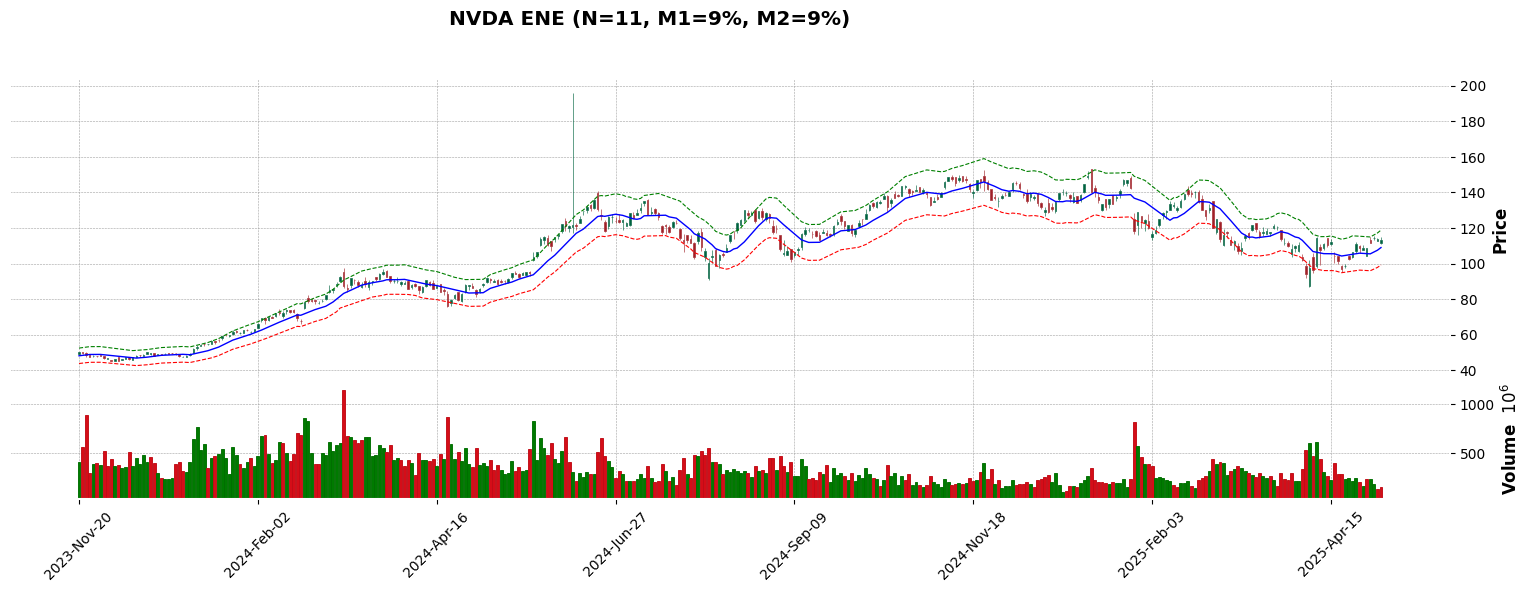

                          Volume        vw    Open   Close    High      Low  \
Date                                                                          
2025-05-06 04:00:00  158525621.0  112.9631  111.48  113.54  114.74  110.822   

                                 t        n       UPPER      LOWER         ENE  
Date                                                                            
2025-05-06 04:00:00  1746504000000  1085874  121.008164  97.024564  109.016364  


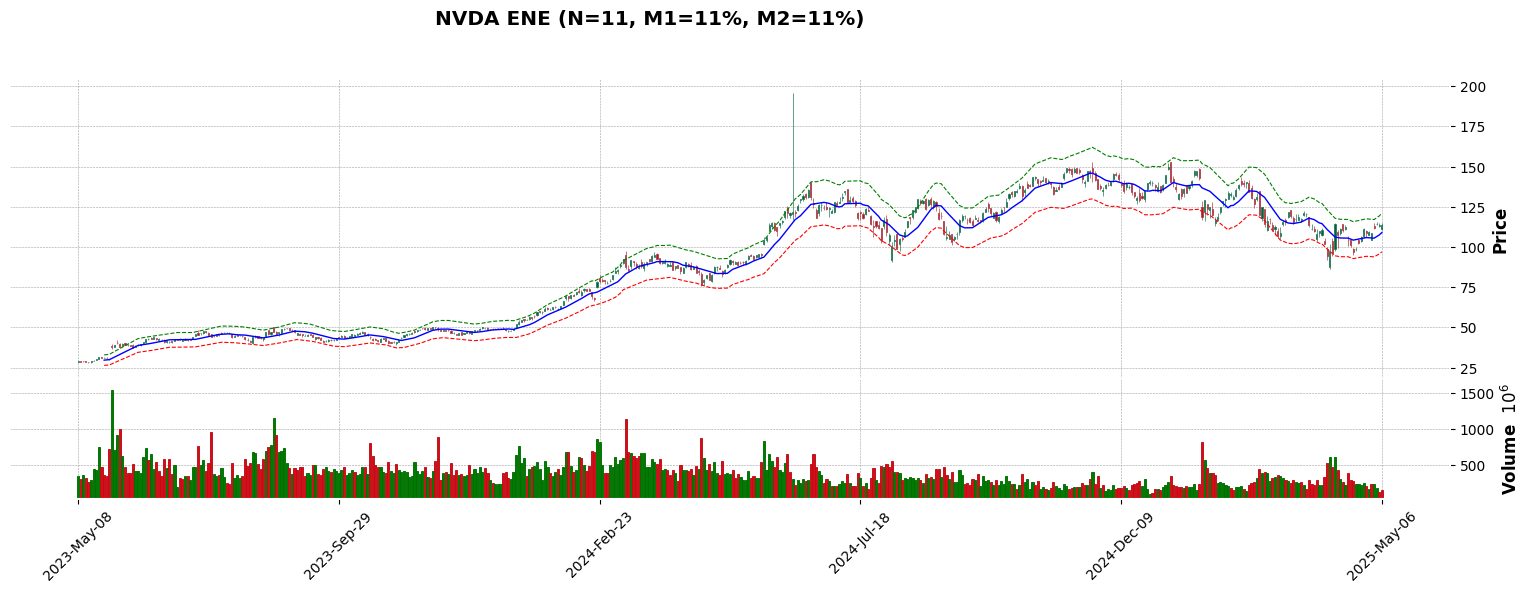

                          Volume        vw    Open   Close    High      Low  \
Date                                                                          
2025-05-06 04:00:00  158525621.0  112.9631  111.48  113.54  114.74  110.822   

                                 t        n      UPPER    LOWER        ENE  
Date                                                                        
2025-05-06 04:00:00  1746504000000  1085874  145.99894  95.2167  120.60782  


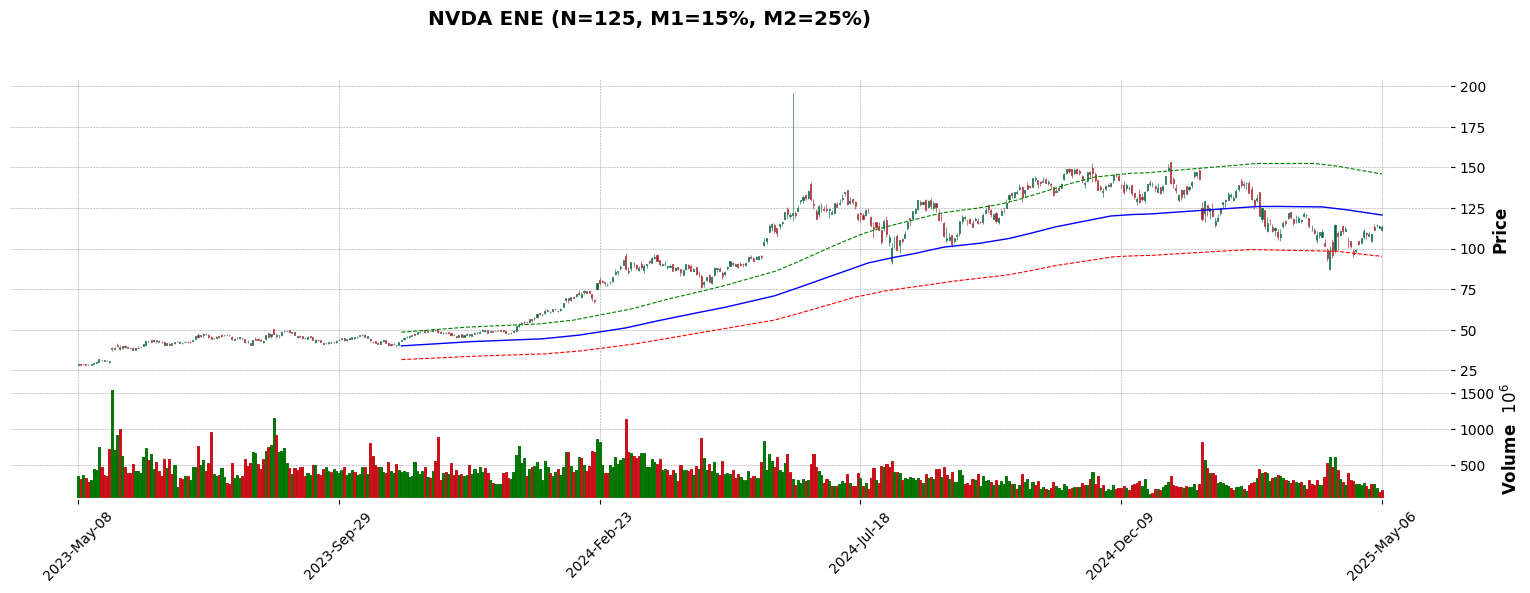

In [73]:
ticker_name = 'NVDA'
data_date = '2025-05-07'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 1
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)

                        Volume        vw    Open   Close    High       Low  \
Date                                                                         
2025-05-09 04:00:00  3621402.0  513.3999  514.25  513.74  515.91  510.2533   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-09 04:00:00  1746763200000  101422  571.699055  477.290036  524.494545  


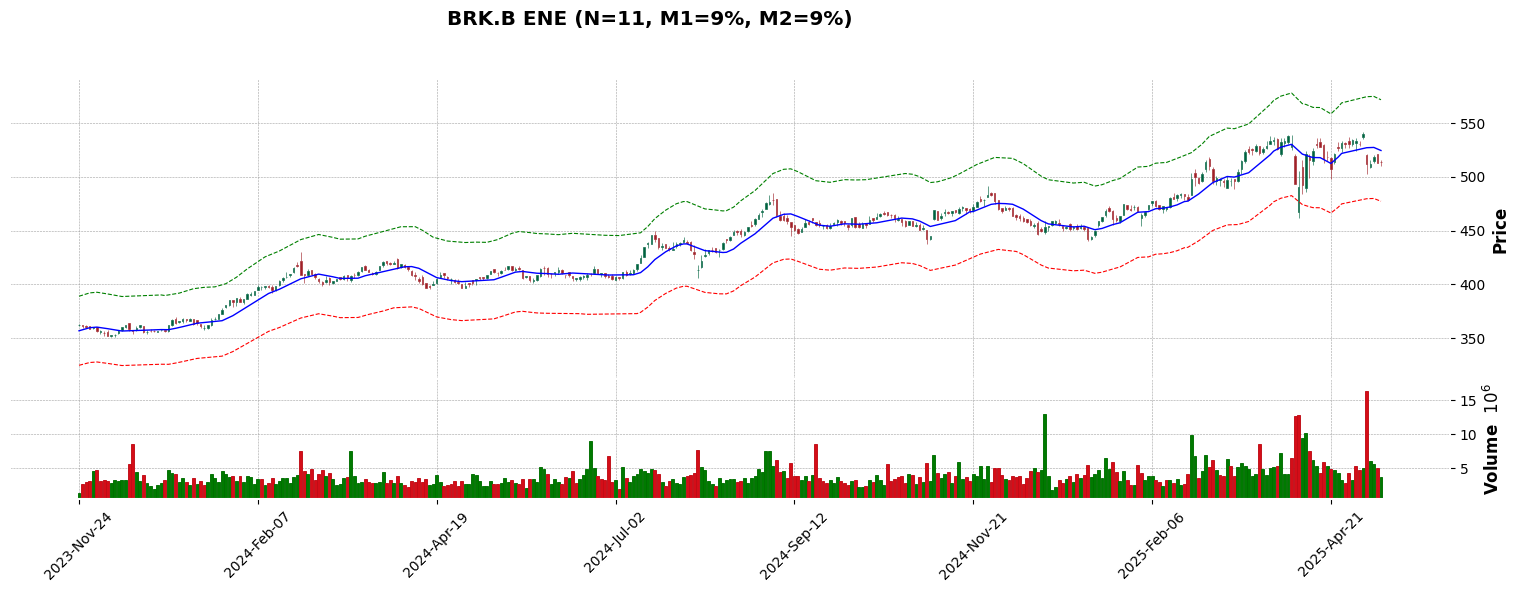

                        Volume        vw    Open   Close    High       Low  \
Date                                                                         
2025-05-09 04:00:00  3621402.0  513.3999  514.25  513.74  515.91  510.2533   

                                 t       n       UPPER       LOWER         ENE  
Date                                                                            
2025-05-09 04:00:00  1746763200000  101422  582.188945  466.800145  524.494545  


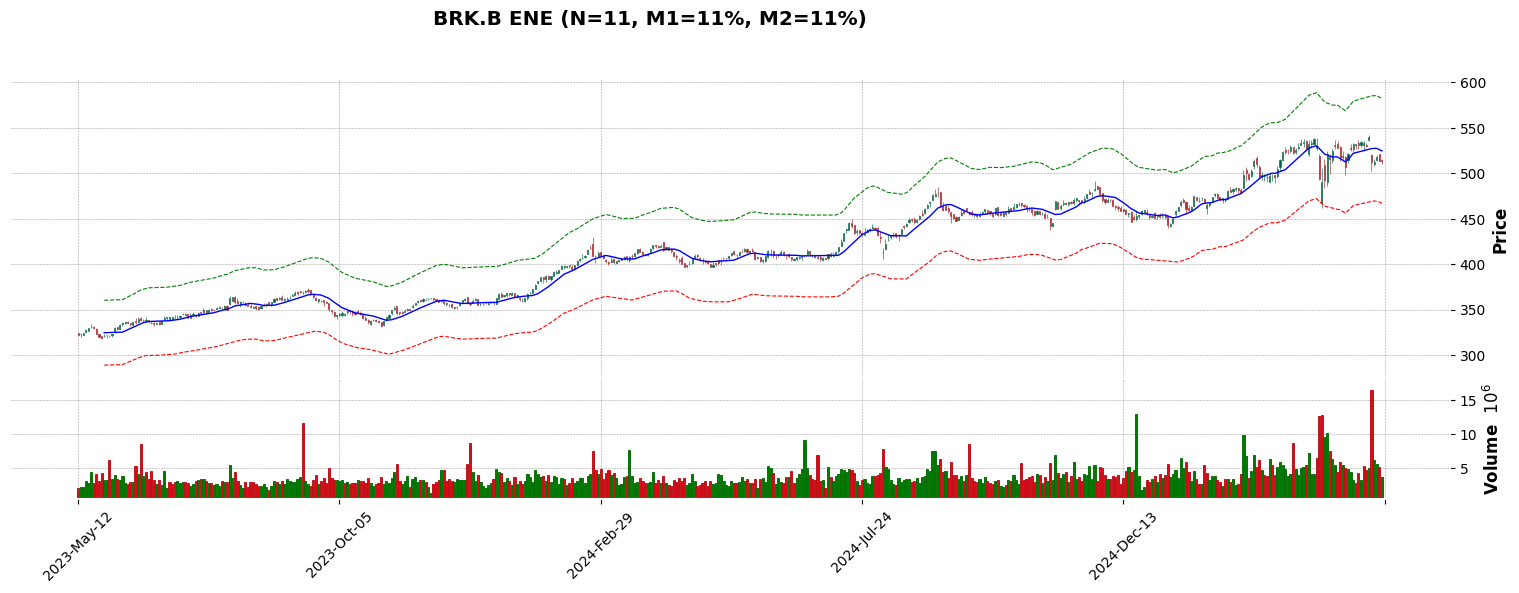

                        Volume        vw    Open   Close    High       Low  \
Date                                                                         
2025-05-09 04:00:00  3621402.0  513.3999  514.25  513.74  515.91  510.2533   

                                 t       n       UPPER      LOWER         ENE  
Date                                                                           
2025-05-09 04:00:00  1746763200000  101422  560.786828  365.73054  463.258684  


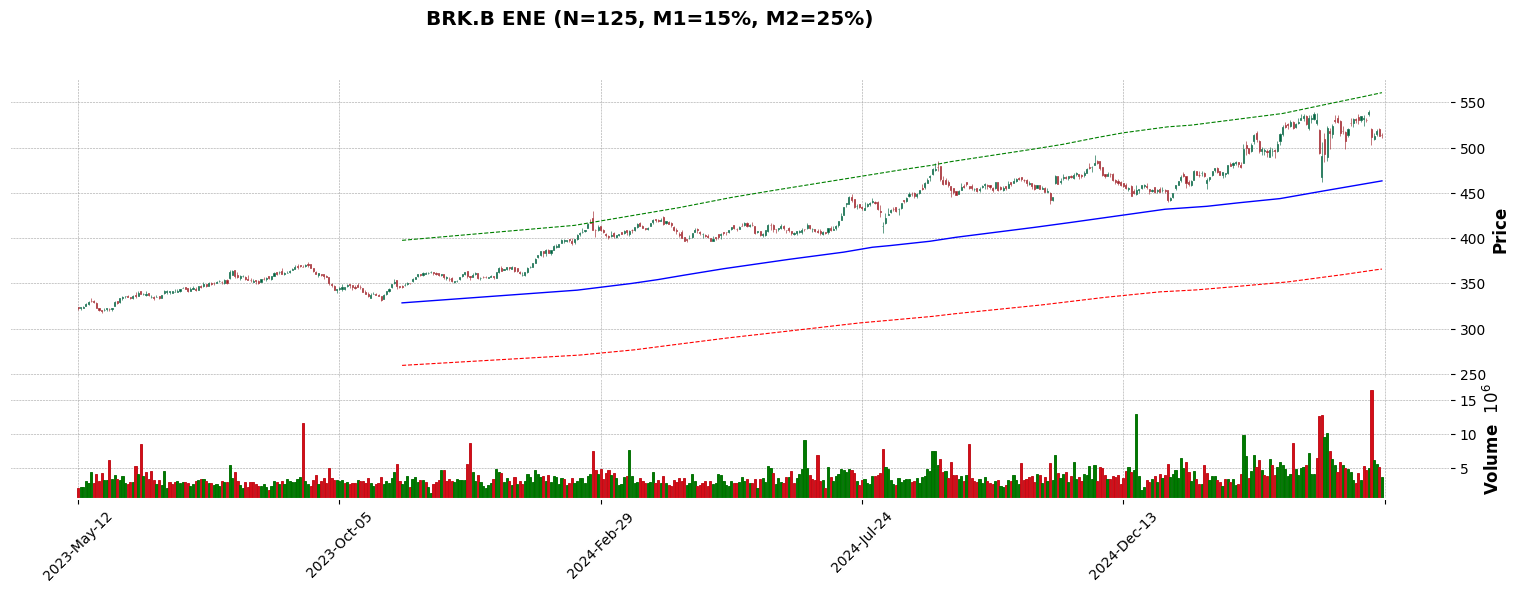

In [104]:
ticker_name = 'BRK.B'
data_date = '2025-05-11'
data_path = f'./data_polygon/{ticker_name}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.09,
        'M2': 0.09,
        'years': 1
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)